In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

X         = np.load("preprocessed/X.npy")         # (90, 30, 126)
y         = np.load("preprocessed/y.npy")         # (90,)
label_map = np.load("preprocessed/label_map.npy", allow_pickle=True).item()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Classes: {label_map}")

X_train: (72, 30, 126) | X_test: (18, 30, 126)
Classes: {0: 'hello', 1: 'thanks', 2: 'iloveyou'}


In [20]:
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),       # thumb
    (0,5),(5,6),(6,7),(7,8),       # index
    (0,9),(9,10),(10,11),(11,12),  # middle
    (0,13),(13,14),(14,15),(15,16),# ring
    (0,17),(17,18),(18,19),(19,20) # pinky
]

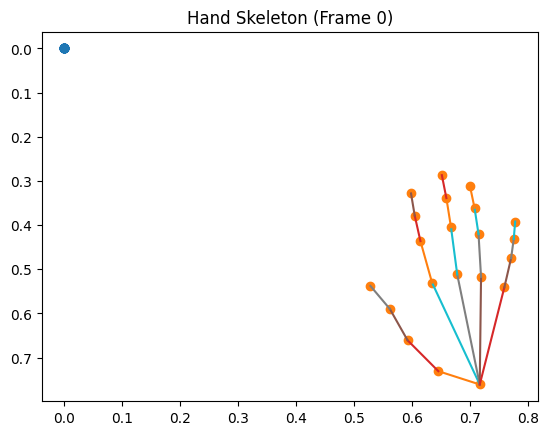

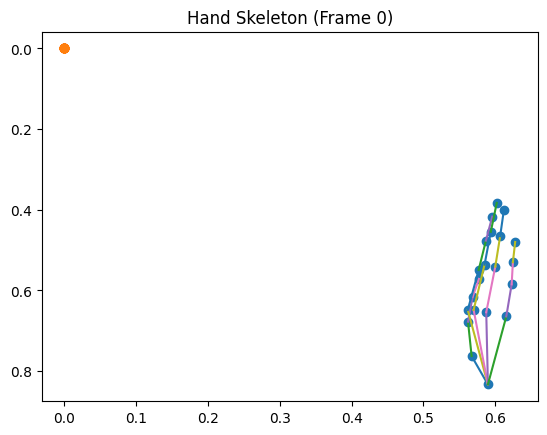

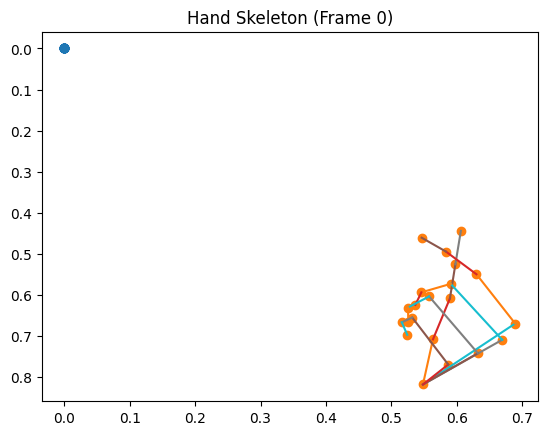

In [45]:
import matplotlib.pyplot as plt
for a in [7, 0 ,1]:

    sample = X_train[a].reshape(30, 42, 3)

    frame = sample[0]  # first frame

    left_hand = frame[:21]
    right_hand = frame[21:]

    plt.figure()

    # Plot points
    plt.scatter(left_hand[:,0], left_hand[:,1])
    plt.scatter(right_hand[:,0], right_hand[:,1])

    # Draw connections
    for conn in HAND_CONNECTIONS:
        plt.plot([left_hand[conn[0],0], left_hand[conn[1],0]],
                 [left_hand[conn[0],1], left_hand[conn[1],1]])

        plt.plot([right_hand[conn[0],0], right_hand[conn[1],0]],
                 [right_hand[conn[0],1], right_hand[conn[1],1]])

    plt.gca().invert_yaxis()
    plt.title("Hand Skeleton (Frame 0)")
    plt.show()

In [46]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (72, 3780)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [52]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_flat, y_train)

print("LR Accuracy:", lr.score(X_test_flat, y_test))

LR Accuracy: 1.0


In [53]:
def plot_cm(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=list(label_map.values()))
    
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

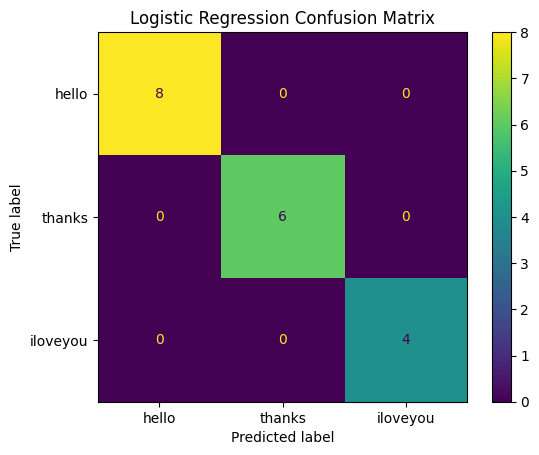

In [54]:
plot_cm(lr, X_test_flat, y_test, "Logistic Regression")